## Respiratory illness triage using computer vision

Task: Build a noise resilient model that is able to identify respiratory illnesses using sound.

Procedure:
1. Get the data - Here we have dataset from kaggle [Respiratory sound database](https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database)
2. Visualize the data - Here we transform the sound into spectograms - a 2D frequency representation of sound
3. Get the model - Since we are working with spectograms(images), we will utilize convulutional neural nets (CNN's) to proceed with the classification task.
4. Test - Test different models, custom made or pretrained models from torch hub


Dataset Structure

The filename format is: {PatientID}_{RecordingIndex}{ChestLocation}{AcquisitionMode}_{RecordingEquipment}.wav

Example: 107_2b3_Ar_mc_AKGC417L.wav


107: Patient ID

2b3: Recording index (2), Chest location (b3),

Ar: Acquisition mode

mc: Recording equipment multichannel

AKGC417L: Microphone type

## Get the data

In [ ]:
#!/bin/bash
!curl -L -o /content/data/respiratory-sound-database.zip\
  https://www.kaggle.com/api/v1/datasets/download/vbookshelf/respiratory-sound-database

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3775M  100 3775M    0     0  82.7M      0  0:00:45  0:00:45 --:--:-- 99.6M


In [ ]:
# unzip the data
import zipfile

with zipfile.ZipFile("/content/data/respiratory-sound-database.zip", 'r') as zip_ref:
  zip_ref.extractall("/content/drive/MyDrive/acoustic_data")

## Visualize the data

In [1]:
import torch
import numpy as np
import torchaudio
import matplotlib.pyplot as plt
from PIL import Image
import soundfile as sf
import os

In [2]:
SPECTOGRAM_DPI = 90
DEFAULT_SAMPLE_RATE = 16000
DEFAULT_HOP_LENGTH = 512
FIXED_WIDTH = 128  # Fixed number of time frames
FIXED_HEIGHT = 64  # Fixed number of mel bins

class AudioProcessor:
    def __init__(self, filepath_, hop_length=DEFAULT_HOP_LENGTH,
                 target_sample_rate=DEFAULT_SAMPLE_RATE,
                 fixed_length_seconds=5.0):  # Fixed duration

        self.hop_length = hop_length
        self.target_sample_rate = target_sample_rate
        self.fixed_length_seconds = fixed_length_seconds
        self.fixed_length_samples = int(target_sample_rate * fixed_length_seconds)

        # Load audio
        aud, original_sr = sf.read(filepath_)
        self.waveform = torch.tensor(aud, dtype=torch.float32)

        # Convert stereo to mono
        if self.waveform.ndim > 1:
            self.waveform = self.waveform.mean(dim=1)

        # Resample if needed
        if original_sr != target_sample_rate:
            resampler = torchaudio.transforms.Resample(
                orig_freq=original_sr,
                new_freq=target_sample_rate
            )
            self.waveform = resampler(self.waveform)

        # Pad or truncate to fixed length
        self.waveform = self._fix_length(self.waveform)

        # Add channel dimension
        self.waveform = self.waveform.unsqueeze(0)

    def _fix_length(self, waveform):
        """Pad or truncate waveform to fixed length"""
        current_length = waveform.shape[0]

        if current_length < self.fixed_length_samples:
            # Pad with zeros
            padding = self.fixed_length_samples - current_length
            waveform = torch.nn.functional.pad(waveform, (0, padding))
        elif current_length > self.fixed_length_samples:
            # Truncate
            waveform = waveform[:self.fixed_length_samples]

        return waveform

    def get_mel_spectrogram(self, n_mels=FIXED_HEIGHT):
        """Generate mel spectrogram with fixed dimensions"""
        mel_spectogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.target_sample_rate,
            n_fft=1024,
            hop_length=self.hop_length,
            n_mels=n_mels
        )
        to_db = torchaudio.transforms.AmplitudeToDB()

        mel_spec = to_db(mel_spectogram(self.waveform))

        # mel_spec shape: [1, n_mels, time_frames]
        # Resize to fixed width if needed
        if mel_spec.shape[2] != FIXED_WIDTH:
            mel_spec = torch.nn.functional.interpolate(
                mel_spec.unsqueeze(0),  # Add batch dimension
                size=(n_mels, FIXED_WIDTH),
                mode='bilinear',
                align_corners=False
            ).squeeze(0)  # Remove batch dimension

        return mel_spec

    def save_spectrogram_as_image(self, output_path, figsize=(4, 4), dpi=SPECTOGRAM_DPI):
        """Save mel spectrogram as image file (for CNN input)"""
        mel_spec = self.get_mel_spectrogram()

        # Create figure without axes for clean image
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.imshow(mel_spec[0].numpy(), origin="lower", aspect="auto", cmap='viridis')
        ax.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
        plt.close()

    def plot_spectrogram(self):
        """Display mel spectrogram with labels"""
        mel_spec = self.get_mel_spectrogram()

        plt.figure(figsize=(10, 4))
        plt.imshow(mel_spec[0].numpy(), origin="lower", aspect="auto", cmap='viridis')
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Mel Spectrogram (Shape: {mel_spec.shape})")
        plt.xlabel("Time")
        plt.ylabel("Mel Frequency")
        plt.tight_layout()
        plt.show()

Spectrogram 1 shape: torch.Size([1, 64, 128])
Spectrogram 2 shape: torch.Size([1, 64, 128])


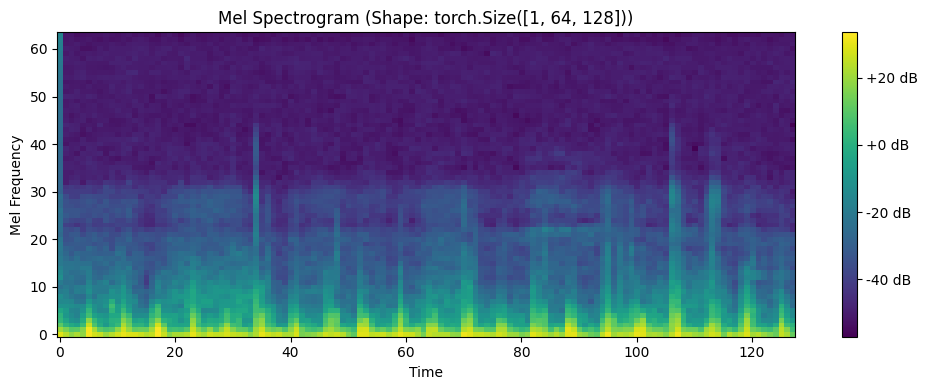

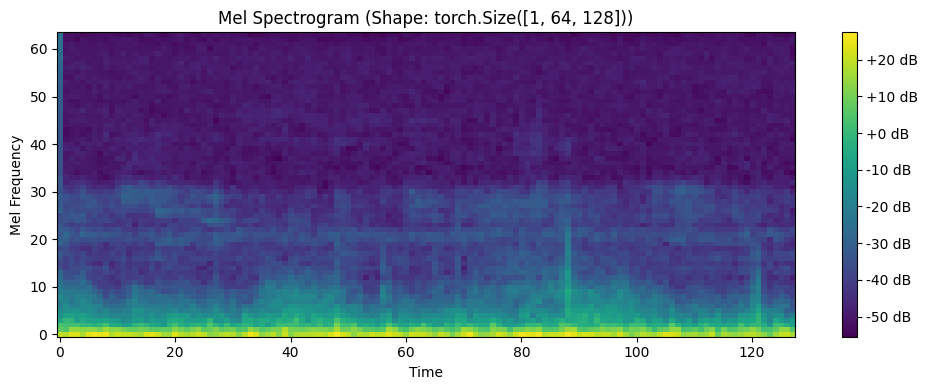

In [3]:
# Visualize
audio1 = AudioProcessor("/content/drive/MyDrive/acoustic_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.wav")
audio2 = AudioProcessor("/content/drive/MyDrive/acoustic_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Pr_sc_Meditron.wav")

spec1 = audio1.get_mel_spectrogram()
spec2 = audio2.get_mel_spectrogram()

print(f"Spectrogram 1 shape: {spec1.shape}")  # Should be [1, 64, 128]
print(f"Spectrogram 2 shape: {spec2.shape}")  # Should be [1, 64, 128]

audio1.plot_spectrogram()
audio2.plot_spectrogram()

## Create a better dataset for easier modelling

In [4]:
import pandas as pd
import os
from pathlib import Path
from tqdm import tqdm
import random

def create_dataset_from_respiratory_sounds(
    audio_dir='/content/drive/MyDrive/acoustic_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
    diagnosis_csv='/content/drive/MyDrive/acoustic_data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv',
    output_dir="/content/new_resp_data",
    target_classes=['COPD', "Healthy", "Pneumonia", "URTI", "Bronchiolitis", "Bronchiectasis"],
    train_ratio=0.8,  # 80% train, 20% validation
    random_seed=42
):
    """
    Create train/val split ensuring no patient appears in both splits
    """

    # Set random seed for reproducibility
    random.seed(random_seed)

    # Load diagnosis data
    diagnosis_df = pd.read_csv(
        diagnosis_csv,
        header=None,
        names=['Patient_ID', 'Diagnosis']
    )

    print("="*70)
    print("📊 ORIGINAL DATASET")
    print("="*70)
    print(f"Total patients: {len(diagnosis_df)}")
    print(f"Diagnoses distribution:")
    print(diagnosis_df['Diagnosis'].value_counts())

    # Filter classes if specified
    if target_classes:
        diagnosis_df = diagnosis_df[diagnosis_df["Diagnosis"].isin(target_classes)]
        print(f"\n✅ Filtered to {len(target_classes)} target classes")
        print(f"Remaining patients: {len(diagnosis_df)}")

    # Get all audio files
    audio_files = list(Path(audio_dir).glob("*.wav"))
    print(f"\n📁 Found {len(audio_files)} total audio files")

    # Group audio files by patient ID
    print("\n🔍 Grouping audio files by patient...")
    patient_audio_map = {}  # {patient_id: [list of audio files]}

    for audio_file in audio_files:
        patient_id = int(audio_file.stem.split('_')[0])

        # Check if patient is in our filtered diagnosis list
        if patient_id not in diagnosis_df['Patient_ID'].values:
            continue

        if patient_id not in patient_audio_map:
            patient_audio_map[patient_id] = []
        patient_audio_map[patient_id].append(audio_file)

    print(f"✅ Found {len(patient_audio_map)} patients with audio files")

    # Split patients (not files!) into train and validation
    print(f"\n✂️ SPLITTING BY PATIENT ({train_ratio:.0%} train, {1-train_ratio:.0%} val)")
    print("="*70)

    # Group patients by diagnosis for stratified split
    diagnosis_patients = {}  # {diagnosis: [list of patient_ids]}

    for patient_id in patient_audio_map.keys():
        diagnosis = diagnosis_df[diagnosis_df['Patient_ID'] == patient_id]['Diagnosis'].iloc[0]

        if diagnosis not in diagnosis_patients:
            diagnosis_patients[diagnosis] = []
        diagnosis_patients[diagnosis].append(patient_id)

    # Perform stratified split per diagnosis
    train_patients = []
    val_patients = []

    for diagnosis, patients in diagnosis_patients.items():
        random.shuffle(patients)  # Shuffle patients

        n_train = int(len(patients) * train_ratio)

        train_patients.extend(patients[:n_train])
        val_patients.extend(patients[n_train:])

        print(f"{diagnosis:20s}: {len(patients):3d} patients → "
              f"Train: {len(patients[:n_train]):3d} | Val: {len(patients[n_train:]):3d}")

    print(f"\n{'TOTAL':20s}: {len(patient_audio_map):3d} patients → "
          f"Train: {len(train_patients):3d} | Val: {len(val_patients):3d}")

    # Create output directory structure
    print(f"\n📂 Creating directory structure...")
    for split in ['train', 'val']:
        for diagnosis in target_classes:
            os.makedirs(os.path.join(output_dir, split, diagnosis), exist_ok=True)

    # Process and save spectrograms
    print(f"\n🎵 PROCESSING AUDIO FILES")
    print("="*70)

    stats = {
        'train': {diagnosis: 0 for diagnosis in target_classes},
        'val': {diagnosis: 0 for diagnosis in target_classes}
    }

    processed = 0
    skipped = 0

    # Process all audio files
    all_audio_to_process = []

    # Collect all files with their split assignment
    for patient_id, audio_files in patient_audio_map.items():
        # Determine split
        if patient_id in train_patients:
            split = 'train'
        else:
            split = 'val'

        # Get diagnosis
        diagnosis = diagnosis_df[diagnosis_df['Patient_ID'] == patient_id]['Diagnosis'].iloc[0]

        for audio_file in audio_files:
            all_audio_to_process.append((audio_file, split, diagnosis))

    # Process with progress bar
    for audio_file, split, diagnosis in tqdm(all_audio_to_process, desc="Creating spectrograms"):
        try:
            # Process audio
            processor = AudioProcessor(str(audio_file))

            # Save spectrogram to appropriate split folder
            output_filename = f"{audio_file.stem}.png"
            output_path = os.path.join(output_dir, split, diagnosis, output_filename)
            processor.save_spectrogram_as_image(output_path)

            stats[split][diagnosis] += 1
            processed += 1

        except Exception as e:
            print(f"\n⚠️ Error processing {audio_file.name}: {e}")
            skipped += 1

    # Print final statistics
    print(f"\n{'='*70}")
    print("✅ PROCESSING COMPLETE!")
    print(f"{'='*70}")
    print(f"Total processed: {processed} files")
    print(f"Total skipped: {skipped} files")

    print(f"\n📊 FINAL DATASET DISTRIBUTION")
    print(f"{'='*70}")
    print(f"{'Class':<20s} {'Train':<10s} {'Val':<10s} {'Total':<10s}")
    print(f"{'-'*70}")

    for diagnosis in sorted(target_classes):
        train_count = stats['train'][diagnosis]
        val_count = stats['val'][diagnosis]
        total = train_count + val_count
        print(f"{diagnosis:<20s} {train_count:<10d} {val_count:<10d} {total:<10d}")

    train_total = sum(stats['train'].values())
    val_total = sum(stats['val'].values())
    grand_total = train_total + val_total

    print(f"{'-'*70}")
    print(f"{'TOTAL':<20s} {train_total:<10d} {val_total:<10d} {grand_total:<10d}")
    print(f"{'='*70}")

    # Verify no patient overlap
    print(f"\n🔍 VERIFICATION")
    print(f"{'='*70}")
    print(f"✅ Train patients: {len(train_patients)}")
    print(f"✅ Val patients: {len(val_patients)}")
    print(f"✅ Patient overlap: {len(set(train_patients) & set(val_patients))} (should be 0!)")

    if len(set(train_patients) & set(val_patients)) == 0:
        print(f"✅ SUCCESS: No patient leakage between train and validation!")
    else:
        print(f"⚠️ WARNING: Patient leakage detected!")

    print(f"\n💾 Dataset saved to: {output_dir}")
    print(f"   📁 {output_dir}/train/")
    print(f"   📁 {output_dir}/val/")

    return stats


# Run the function
stats = create_dataset_from_respiratory_sounds()

📊 ORIGINAL DATASET
Total patients: 126
Diagnoses distribution:
Diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64

✅ Filtered to 6 target classes
Remaining patients: 123

📁 Found 920 total audio files

🔍 Grouping audio files by patient...
✅ Found 123 patients with audio files

✂️ SPLITTING BY PATIENT (80% train, 20% val)
COPD                :  64 patients → Train:  51 | Val:  13
Bronchiolitis       :   6 patients → Train:   4 | Val:   2
URTI                :  14 patients → Train:  11 | Val:   3
Bronchiectasis      :   7 patients → Train:   5 | Val:   2
Healthy             :  26 patients → Train:  20 | Val:   6
Pneumonia           :   6 patients → Train:   4 | Val:   2

TOTAL               : 123 patients → Train:  95 | Val:  28

📂 Creating directory structure...

🎵 PROCESSING AUDIO FILES


Creating spectrograms: 100%|██████████| 917/917 [04:12<00:00,  3.63it/s]


✅ PROCESSING COMPLETE!
Total processed: 917 files
Total skipped: 0 files

📊 FINAL DATASET DISTRIBUTION
Class                Train      Val        Total     
----------------------------------------------------------------------
Bronchiectasis       8          8          16        
Bronchiolitis        9          4          13        
COPD                 529        264        793       
Healthy              28         7          35        
Pneumonia            15         22         37        
URTI                 16         7          23        
----------------------------------------------------------------------
TOTAL                605        312        917       

🔍 VERIFICATION
✅ Train patients: 95
✅ Val patients: 28
✅ Patient overlap: 0 (should be 0!)
✅ SUCCESS: No patient leakage between train and validation!

💾 Dataset saved to: /content/new_resp_data
   📁 /content/new_resp_data/train/
   📁 /content/new_resp_data/val/


## Modelling

1. Create dataloaders to load data

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ========================
# 2️⃣ Load datasets
# ========================
train_dataset = datasets.ImageFolder(
    '/content/new_resp_data/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    '/content/new_resp_data/val',
    transform=val_transform
)

print(f"Train: {len(train_dataset)} samples")
print(f"Val: {len(val_dataset)} samples")
print(f"Classes: {train_dataset.classes}")

Train: 605 samples
Val: 312 samples
Classes: ['Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Pneumonia', 'URTI']


In [7]:
# Data loader
from torch.utils.data import WeightedRandomSampler
from collections import Counter

def create_balanced_sampler(dataset):
    labels = [label for _, label in dataset]
    class_counts = Counter(labels)
    print(f"Class counts: {class_counts}")

    # Weight inversely proportional to frequency
    sample_weights = [1.0 / class_counts[label] for _, label in dataset]

    # num_samples: make sure each class can be repeated enough
    num_samples = max(class_counts.values()) * len(class_counts)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=num_samples,
        replacement=True
    )
    return sampler

sampler = create_balanced_sampler(train_dataset)

# ========================
# 4️⃣ DataLoaders
# ========================
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Class counts: Counter({2: 529, 3: 28, 5: 16, 4: 15, 1: 9, 0: 8})
Training batches: 100
Validation batches: 10


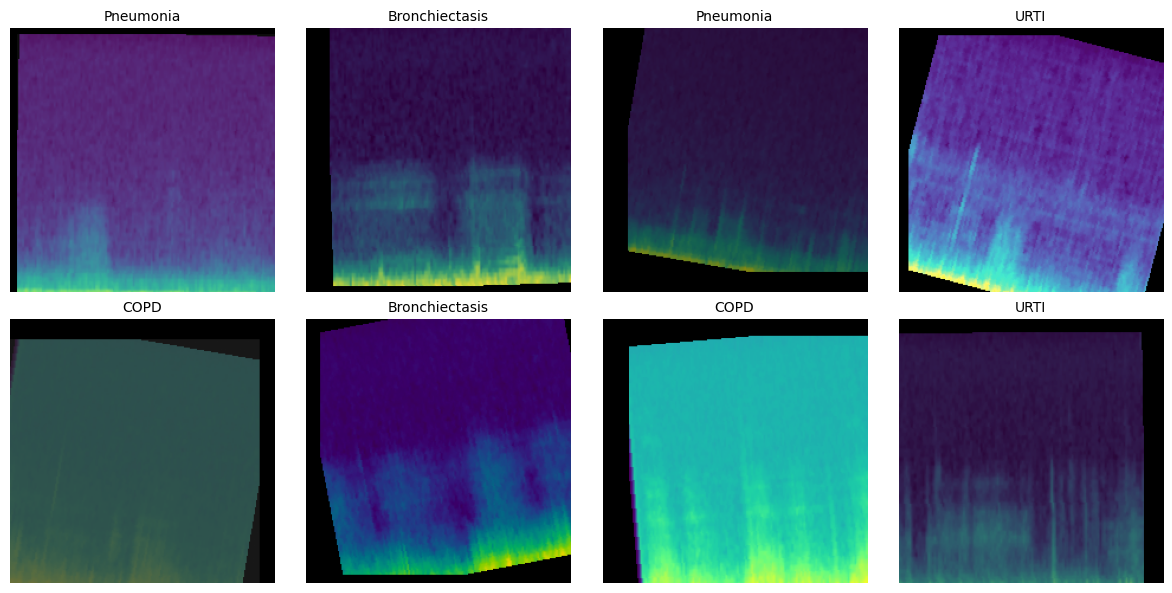

In [8]:
def show_batch_from_loader(loader, num_images=8):
    """
    Get a batch from loader and display it

    """
    # Get one batch
    images, labels = next(iter(loader))

    # Get class names from the dataset
    class_names = loader.dataset.classes

    # Make sure we don't try to show more images than we have
    num_images = min(num_images, len(images))

    # Create a grid
    rows = 2
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(num_images):
        # Get image and label
        img = images[i]
        label = labels[i].item()

        # Convert from tensor to displayable format
        # Reverse the normalization
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)

        # Clip to [0, 1] range
        img = torch.clamp(img, 0, 1)

        # Move channels to last dimension for matplotlib
        img = img.permute(1, 2, 0).numpy()

        # Display
        axes[i].imshow(img)
        axes[i].set_title(f"{class_names[label]}", fontsize=10)
        axes[i].axis('off')

    # Hide any unused subplots
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


# USAGE:
show_batch_from_loader(train_loader, num_images=8)

## Load pretrained model

In [9]:
import torch.nn as nn
from torchvision import models

In [10]:
model = models.resnet18(pretrained=True)
print("Pre-trained ResNet18 loaded!")
print(f"\nModel structure:")
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]

Pre-trained ResNet18 loaded!

Model structure:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

In [11]:
print("\nOriginal final layer:")
print(model.fc)


Original final layer:
Linear(in_features=512, out_features=1000, bias=True)


## Feature extraction

In [12]:
for param in model.parameters():
    param.requires_grad = False  # Don't update these weights!

print("All layers frozen!")

num_features = model.fc.in_features  # Get input size (512)
model.fc = nn.Linear(num_features, len(train_dataset.classes))

print(f"New final layer: {model.fc}")

All layers frozen!
New final layer: Linear(in_features=512, out_features=6, bias=True)


In [13]:
## loss func and optimizer
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

labels = [label for _, label in train_dataset]
class_counts = Counter(labels)
total_samples = sum(class_counts.values())
class_weights = [total_samples / class_counts[i] for i in range(len(train_dataset.classes))]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Using device: cuda


In [14]:
params_to_train = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.Adam(
    params_to_train,
    lr=0.001
)

print(f"Optimizer created!")
print(f"Training {len(params_to_train)} parameter groups")

Optimizer created!
Training 2 parameter groups


In [15]:
# Scheduler to steadily decay the lr

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    correct = 0
    total = 0

    # Loop through all batches
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Step 1: Zero the gradients
        optimizer.zero_grad()

        # Step 2: Forward pass
        outputs = model(images)

        # Step 3: Calculate loss
        loss = criterion(outputs, labels)

        # Step 4: Backward pass
        loss.backward()

        # Step 5: Update weights
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * images.size(0)

        # Get predictions
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [17]:
def validate(model, val_loader, criterion, device):
    """
    Evaluate the model on validation set
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    correct = 0
    total = 0

    # No gradient calculation needed (saves memory)
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass only
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [18]:
def train(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=10, device='cuda'):
  best_acc = 0.0
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
  for epoch in range(num_epochs):
      print(f"\nEpoch {epoch+1}/{num_epochs}")
      print("-" * 30)

      train_loss, train_acc = train_one_epoch(
          model, train_loader, criterion, optimizer, device
      )
      # Validate
      val_loss, val_acc = validate(
          model, val_loader, criterion, device
      )
      # Save history
      history['train_loss'].append(train_loss)
      history['train_acc'].append(train_acc)
      history['val_loss'].append(val_loss)
      history['val_acc'].append(val_acc)

      # Print stats
      print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
      print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

      # Save best model
      if val_acc > best_acc:
          best_acc = val_acc
          torch.save(model.state_dict(), 'best_model.pth')
          print(f"Saved new best model! (Acc: {best_acc:.2f}%)")
  print(f"\n Training complete! Best validation accuracy: {best_acc:.2f}%")
  return history

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=30,
    device=device
)


Epoch 1/30
------------------------------
Train Loss: 7.0166 | Train Acc: 32.83%
Val Loss:   2.1795 | Val Acc:   4.81%
Saved new best model! (Acc: 4.81%)

Epoch 2/30
------------------------------
Train Loss: 5.0369 | Train Acc: 48.36%
Val Loss:   0.9943 | Val Acc:   53.21%
Saved new best model! (Acc: 53.21%)

Epoch 3/30
------------------------------
Train Loss: 4.2899 | Train Acc: 62.35%
Val Loss:   0.6198 | Val Acc:   85.58%
Saved new best model! (Acc: 85.58%)

Epoch 4/30
------------------------------
Train Loss: 3.9826 | Train Acc: 66.67%
Val Loss:   0.5000 | Val Acc:   88.46%
Saved new best model! (Acc: 88.46%)

Epoch 5/30
------------------------------
Train Loss: 3.7127 | Train Acc: 68.87%
Val Loss:   0.3401 | Val Acc:   90.06%
Saved new best model! (Acc: 90.06%)

Epoch 6/30
------------------------------
Train Loss: 3.3774 | Train Acc: 73.41%
Val Loss:   0.3763 | Val Acc:   90.06%

Epoch 7/30
------------------------------
Train Loss: 3.3559 | Train Acc: 71.83%
Val Loss:   0.

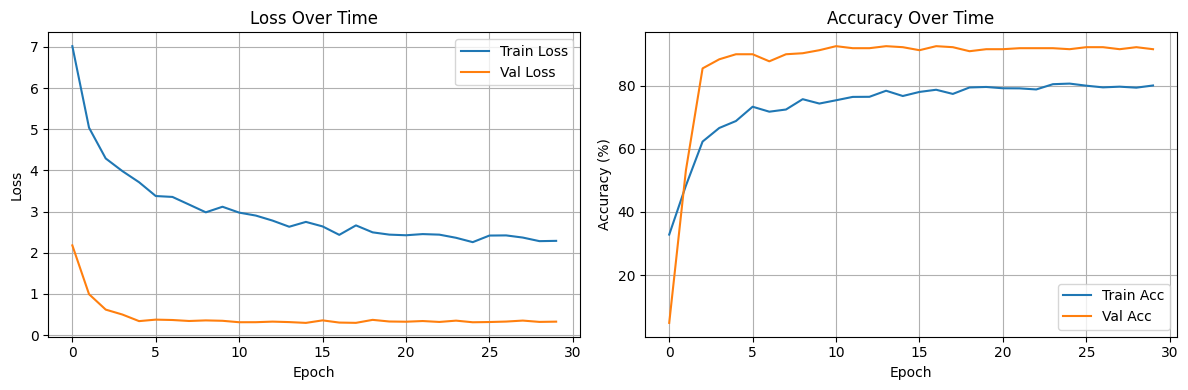

In [19]:
def plot_history(history):
    """
    Plot training curves
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot loss
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Over Time')
    ax1.legend()
    ax1.grid(True)

    # Plot accuracy
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy Over Time')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

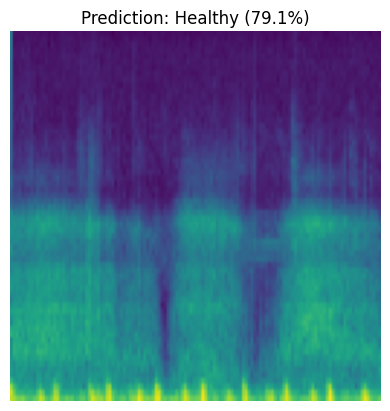

('Healthy', 79.05547618865967)

In [ ]:
def predict_image(model, image_path, transform, device, class_names):
    """
    Predict a single image
    """
    from PIL import Image

    # Load and transform image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    image_tensor = image_tensor.to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_pct = confidence.item() * 100

    # Display
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence_pct:.1f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence_pct

# Use it
predict_image(
    model=model,
    image_path='/content/new_resp_data/train/Healthy/121_1b1_Tc_sc_Meditron.png',
    transform=val_transform,
    device=device,
    class_names=train_dataset.classes
)

## Fine tune the transfer learning model

In [ ]:
model2 = models.resnet18(pretrained=True)
print("Pre-trained ResNet18 loaded!")
print(f"\nModel structure:")
print(model2)

Pre-trained ResNet18 loaded!

Model structure:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

In [ ]:
# Freeze early layers (layers 1-6)
for name, param in model2.named_parameters():
    if "layer4" not in name and "fc" not in name:  # Skip layer4 and fc
        param.requires_grad = False

# Replace final layer
num_features = model2.fc.in_features
model2.fc = nn.Linear(num_features, 6)

print("Model ready for fine-tuning!")
print("\nTrainable layers:")
for name, param in model2.named_parameters():
    if param.requires_grad:
        print(f"  {name}")

Model ready for fine-tuning!

Trainable layers:
  layer4.0.conv1.weight
  layer4.0.bn1.weight
  layer4.0.bn1.bias
  layer4.0.conv2.weight
  layer4.0.bn2.weight
  layer4.0.bn2.bias
  layer4.0.downsample.0.weight
  layer4.0.downsample.1.weight
  layer4.0.downsample.1.bias
  layer4.1.conv1.weight
  layer4.1.bn1.weight
  layer4.1.bn1.bias
  layer4.1.conv2.weight
  layer4.1.bn2.weight
  layer4.1.bn2.bias
  fc.weight
  fc.bias


In [ ]:
## loss func and optimizer
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = model2.to(device)
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss()

Using device: cuda


In [ ]:
params_to_train = [p for p in model2.parameters() if p.requires_grad]

optimizer = optim.Adam(
    params_to_train,
    lr=0.001
)

print(f"Optimizer created!")
print(f"Training {len(params_to_train)} parameter groups")

Optimizer created!
Training 17 parameter groups


In [ ]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

In [ ]:
history = train(
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device=device
)


Epoch 1/10
------------------------------
Train Loss: 0.7658 | Train Acc: 71.24%
Val Loss:   0.3167 | Val Acc:   95.19%
Saved new best model! (Acc: 95.19%)

Epoch 2/10
------------------------------
Train Loss: 0.2846 | Train Acc: 90.08%
Val Loss:   0.2342 | Val Acc:   94.87%

Epoch 3/10
------------------------------
Train Loss: 0.1418 | Train Acc: 94.21%
Val Loss:   0.3502 | Val Acc:   92.95%

Epoch 4/10
------------------------------
Train Loss: 0.1536 | Train Acc: 95.54%
Val Loss:   0.3638 | Val Acc:   92.63%

Epoch 5/10
------------------------------
Train Loss: 0.0919 | Train Acc: 96.69%
Val Loss:   0.3915 | Val Acc:   91.03%

Epoch 6/10
------------------------------
Train Loss: 0.0879 | Train Acc: 97.02%
Val Loss:   0.3083 | Val Acc:   91.03%

Epoch 7/10
------------------------------
Train Loss: 0.0567 | Train Acc: 98.18%
Val Loss:   0.3444 | Val Acc:   91.99%

Epoch 8/10
------------------------------
Train Loss: 0.0696 | Train Acc: 98.02%
Val Loss:   0.3585 | Val Acc:   92.

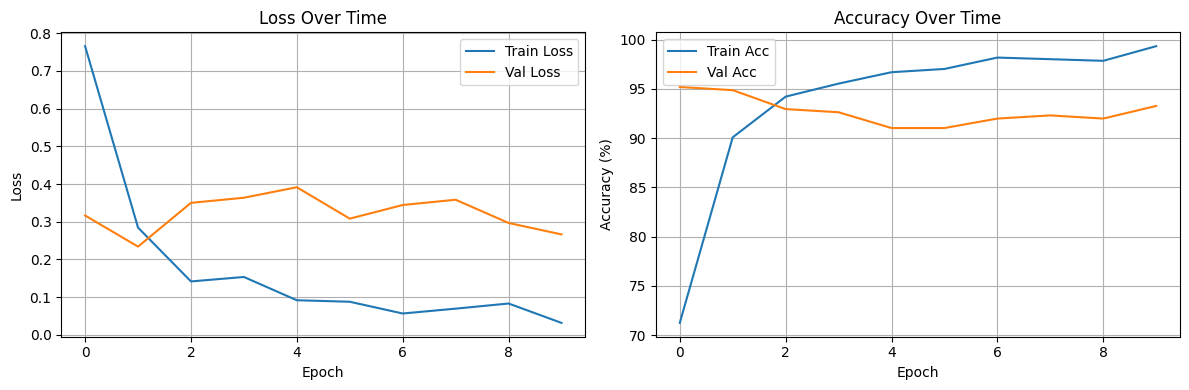

In [ ]:
plot_history(history)